# The Success of the restaurants in 2026

### First of all **WHAT IS SUCCESS ???** 

There are a lot of ways to measure "success", mainly 3:

- Perceived success: The rating, reviews, popularity. Easy to measure. Easy to find data. The problem -> Easy to manipulate. Restaurants buy reviews or delete the bad ones

- Economical success: Net profit, ROI, ROA, Customer Retention Rate... They are good indicators but the data about them is hard to find and create a dataframe for thousands of restaurants

- Gastronomical success: Technique, Quality, Product, Consistency... It indicates the Real quality but is really hard to measure with public data. 

This project will use ratings as a proxy for success, while acknowledging their limitations in capturing real quality and business performance so they will be critically evaluated
due to their inherent biases, ratings reflect accessibility, not excellence, a 4.8 rating might be technically mediocre and a 4.2 gastronomically excellent.
Success in restaurants is multi-dimensional 

In [ ]:
import pandas as pd
import numpy as np
import polars as pl
import yaml

In [2]:
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [3]:
df1 = pl.read_csv(config["input_data"]["file_1"])
df1

restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,claimed,awards,popularity_detailed,popularity_generic,top_tags,price_level,price_range,meals,cuisines,special_diets,features,vegetarian_friendly,vegan_options,gluten_free,original_open_hours,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,default_language,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""g10001637-d10002227""","""Le 147""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Haute-Vienne""","""Saint-Jouvent""","""10 Maison Neuve, 87510 Saint-J…",45.961674,1.169131,"""Claimed""",null,"""#1 of 2 Restaurants in Saint-J…","""#1 of 2 places to eat in Saint…","""Cheap Eats, French""","""€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Wheelch…","""N""","""N""","""N""",null,null,null,null,4.0,36.0,"""English""",2.0,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,null,null
"""g10001637-d14975787""","""Le Saint Jouvent""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Haute-Vienne""","""Saint-Jouvent""","""16 Place de l Eglise, 87510 Sa…",45.95704,1.20548,"""Unclaimed""",null,"""#2 of 2 Restaurants in Saint-J…","""#2 of 2 places to eat in Saint…","""Cheap Eats""","""€""",null,null,null,null,null,"""N""","""N""","""N""",null,null,null,null,4.0,5.0,"""All languages""",5.0,2.0,2.0,1.0,0.0,0.0,null,null,null,null,null
"""g10002858-d4586832""","""Au Bout du Pont""","""[""Europe"", ""France"", ""Centre-V…","""France""","""Centre-Val de Loire""","""Berry""","""Rivarennes""","""2 rue des Dames, 36800 Rivaren…",46.635895,1.386133,"""Claimed""",null,"""#1 of 1 Restaurant in Rivarenn…","""#1 of 1 places to eat in Rivar…","""Cheap Eats, French, European""","""€""",null,"""Dinner, Lunch, Drinks""","""French, European""",null,"""Reservations, Seating, Table S…","""N""","""N""","""N""",null,null,null,null,5.0,13.0,"""English""",4.0,3.0,1.0,0.0,0.0,0.0,null,null,null,null,null
"""g10002986-d3510044""","""Le Relais de Naiade""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Correze""","""Lacelle""","""9 avenue Porte de la Correze 1…",45.64261,1.82446,"""Claimed""",null,"""#1 of 1 Restaurant in Lacelle""","""#1 of 1 places to eat in Lacel…","""Cheap Eats, French""","""€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Serves …","""N""","""N""","""N""",null,null,null,null,4.0,34.0,"""English""",1.0,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,null,null
"""g10022428-d9767191""","""Relais Du MontSeigne""","""[""Europe"", ""France"", ""Occitani…","""France""","""Occitanie""","""Aveyron""","""Saint-Laurent-de-Levezou""","""route du Montseigne, 12620 Sai…",44.20886,2.96047,"""Unclaimed""",null,"""#1 of 1 Restaurant in Saint-La…","""#1 of 1 places to eat in Saint…","""Mid-range, French""","""€€-€€€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Wheelch…","""N""","""N""","""N""",null,null,null,null,4.5,11.0,"""All languages""",11.0,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""g9710275-d10770782""","""Complex Popas Pacurari""","""[""Europe"", ""Romania"", ""Northea…","""Romania""","""Northeast Romania""","""Iasi County""",null,"""Soseaua Pacurari, Valea Lupulu…",47.17295,27.51911,"""Unclaimed""",null,"""#1 of 1 Restaurant in Valea Lu…","""#1 of 1 places to eat in Valea…",null,null,null,"""Lunch, Dinner""",null,null,null,"""N""","""N""","""N""","""{""Mon"": [""10:00-22:00""], ""Tue""…",7.0,84.0,7.0,2.5,2.0,"""English""",1.0,0.0,0.0,0.0,0.0,1.0,null,null,null,null,null
"""g9716321-d15026574""","""Casa Pastravarului DORIPESCO""","""[""Europe"", 

In [4]:
# filter by country Spain
df_spain = df1.filter(pl.col("country") == "Spain")
df_spain

restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,claimed,awards,popularity_detailed,popularity_generic,top_tags,price_level,price_range,meals,cuisines,special_diets,features,vegetarian_friendly,vegan_options,gluten_free,original_open_hours,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,default_language,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""g10021880-d13763192""","""Taberna La Sacristia""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del Concejo 19, 41870 Az…",37.51928,-6.26885,"""Unclaimed""",null,"""#4 of 5 Restaurants in Aznalco…","""#4 of 6 places to eat in Aznal…","""Spanish""",null,null,null,"""Spanish""",null,null,"""N""","""N""","""N""",null,null,null,null,3.0,1.0,"""English""",1.0,0.0,0.0,1.0,0.0,0.0,null,null,null,null,null
"""g10021880-d15758746""","""Tasca el Capricho""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del 28 de Febrero 9, 418…",37.52065,-6.26822,"""Unclaimed""",null,"""#3 of 5 Restaurants in Aznalco…","""#3 of 6 places to eat in Aznal…","""Spanish""",null,null,null,"""Spanish""",null,null,"""N""","""N""","""N""",null,null,null,null,5.0,2.0,"""All languages""",2.0,2.0,0.0,0.0,0.0,0.0,null,null,null,null,null
"""g10021880-d19332558""","""Bar Las Adelfas""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle Perdon N° 23 Capilla de …",37.52428,-6.27144,"""Claimed""",null,"""#5 of 5 Restaurants in Aznalco…","""#5 of 6 places to eat in Aznal…","""Mediterranean, Spanish, Grill,…",null,null,"""Breakfast, Lunch, Dinner, Brun…","""Mediterranean, Spanish, Grill,…",null,null,"""N""","""N""","""N""","""{""Mon"": [], ""Tue"": [""19:30-23:…",6.0,51.0,6.0,3.0,2.0,"""All languages""",2.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null
"""g10021880-d19468788""","""El Rincon nº 7""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del Concejo 60, 41870 Az…",37.51714,-6.2686,"""Claimed""",null,"""#1 of 5 Restaurants in Aznalco…","""#1 of 6 places to eat in Aznal…","""Mid-range, Steakhouse, Cafe, S…","""€€-€€€""","""€2-€18""","""Lunch, Dinner, Drinks""","""Steakhouse, Cafe, Dining bars,…",null,null,"""N""","""N""","""N""","""{""Mon"": [], ""Tue"": [], ""Wed"": …",4.0,23.0,7.0,5.0,18.0,"""All languages""",18.0,17.0,1.0,0.0,0.0,0.0,null,null,null,null,null
"""g10021880-d19847377""","""Nuevo jacaranda""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del 28 de Febrero 2, 418…",37.52088,-6.26844,"""Claimed""",null,null,null,null,null,null,null,null,null,"""Reservations""","""N""","""N""","""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""g9871604-d13931661""","""Mesón La Parrillada""","""[""Europe"", ""Spain"", ""Galicia"",…","""Spain""","""Galicia""","""Province of A Coruna""",null,"""Salida de la autovia, Coiros S…",null,null,"""Unclaimed""",null,"""#4 of 4 Restaurants in Coiros""","""#4 of 5 places to eat in Coiro…","""Spanish""",null,null,null,"""Spanish""",null,"""Reservations""","""N""","""N""","""N""",null,null,null,null,3.5,9.0,"""All languages""",9.0,5.0,1.0,0.0,1.0,2.0,null,null,null,null,null
"""g9871604-d8738469""","""Restaurante La Paz""","""[""Europe"", ""Spain"", ""Galicia"",…","""Spain""","""Galicia""","""Province of A Coruna""",null,"""Lg. Espenuca, 3, 15316, Coiros…",43.26089,-8.156289,"""Unclaimed""",null,"""#3 of 4 Restaurants in C

In [5]:
# save the filtered dataframe to a new csv file
df_spain.write_csv(config["output_data"]["file_1"])


In [6]:
# read this new csv file to check it in pandas
df_spain_check = pd.read_csv(config["output_data"]["file_1"])
df_spain_check.head()

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10021880-d13763192,Taberna La Sacristia,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",37.51928,-6.26885,...,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,g10021880-d15758746,Tasca el Capricho,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",37.52065,-6.26822,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10021880-d19332558,Bar Las Adelfas,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle Perdon N° 23 Capilla de La Cruz, 41870 A...",37.52428,-6.27144,...,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,g10021880-d19468788,El Rincon nº 7,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 60, 41870 Aznalcollar Spain",37.51714,-6.26860,...,17.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,g10021880-d19847377,Nuevo jacaranda,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 2, 41870 Aznalcollar S...",37.52088,-6.26844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# save df_spain_check into the variable df for better usage
df = df_spain_check
df.head()

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10021880-d13763192,Taberna La Sacristia,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",37.51928,-6.26885,...,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,g10021880-d15758746,Tasca el Capricho,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",37.52065,-6.26822,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10021880-d19332558,Bar Las Adelfas,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle Perdon N° 23 Capilla de La Cruz, 41870 A...",37.52428,-6.27144,...,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,g10021880-d19468788,El Rincon nº 7,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 60, 41870 Aznalcollar Spain",37.51714,-6.26860,...,17.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,g10021880-d19847377,Nuevo jacaranda,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 2, 41870 Aznalcollar S...",37.52088,-6.26844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape

(157479, 42)

In [10]:
# see the names of the columns
df.columns

Index(['restaurant_link', 'restaurant_name', 'original_location', 'country',
       'region', 'province', 'city', 'address', 'latitude', 'longitude',
       'claimed', 'awards', 'popularity_detailed', 'popularity_generic',
       'top_tags', 'price_level', 'price_range', 'meals', 'cuisines',
       'special_diets', 'features', 'vegetarian_friendly', 'vegan_options',
       'gluten_free', 'original_open_hours', 'open_days_per_week',
       'open_hours_per_week', 'working_shifts_per_week', 'avg_rating',
       'total_reviews_count', 'default_language',
       'reviews_count_in_default_language', 'excellent', 'very_good',
       'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
       'keywords'],
      dtype='str')

### There are some bars and coffee shops in the dataset, but we are only interested in restaurants. Let's check how many restaurants we have in the dataset.



In [13]:
# Let's check the value counts of the columns "top_tags" and "cuisines"
print(df["top_tags"].value_counts())



top_tags
Mid-range, Spanish                                           9472
Spanish                                                      7554
Mid-range, Mediterranean, Spanish                            6870
Mid-range, Mediterranean, European, Spanish                  6642
Cheap Eats, Spanish                                          5544
                                                             ... 
Cheap Eats, Colombian, Vegetarian Friendly, Vegan Options       1
Italian, American, German, Fast food                            1
Mid-range, European, Deli, Wine Bar                             1
Mid-range, Contemporary, Pub, Healthy                           1
Cheap Eats, Wine Bar, Dining bars                               1
Name: count, Length: 10289, dtype: int64


In [14]:
print(df["cuisines"].value_counts())

cuisines
Spanish                                              26235
Mediterranean, Spanish                               10622
Spanish, Mediterranean                                5450
Mediterranean, European, Spanish                      3845
Cafe                                                  3842
                                                     ...  
Contemporary, Pub, Healthy, Wine Bar, Street Food        1
Steakhouse, Barbecue, European, Spanish, Grill           1
Cafe, Spanish, Grill, Steakhouse                         1
Wine Bar, Dining bars                                    1
Mediterranean, Spanish, Steakhouse, Cafe, Diner          1
Name: count, Length: 17659, dtype: int64


In [16]:
# we will apply a filter on cuisines
exclude_keywords = ['cafe', 'bar', 'pub', 'fast food', 'wine bar', 
                    'diner', 'deli', 'coffee', 'bakery', 'juice bar']

mask = ~df['cuisines'].str.lower().str.contains('|'.join(exclude_keywords), na=False)
df_filtered = df[mask]
df_filtered

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10021880-d13763192,Taberna La Sacristia,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",37.519280,-6.268850,...,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,g10021880-d15758746,Tasca el Capricho,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",37.520650,-6.268220,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,g10021880-d19847377,Nuevo jacaranda,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 2, 41870 Aznalcollar S...",37.520880,-6.268440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,g10052043-d12414243,Casal M&M,"[""Europe"", ""Spain"", ""Catalonia"", ""Province of ...",Spain,Catalonia,Province of Barcelona,NaN,"c/josep Fornells s/n Casal Del Poble, 08231 Ul...",41.526910,1.958510,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
11,g1006045-d10028667,La Dorotea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Plaza De Nuestra Señora Del Socorro, 6, Tejeda...",27.995207,-15.615803,...,17.0,3.0,1.0,1.0,0.0,4.5,4.5,4.5,NaN,"fried cheese, canarian potatoes, fries, friend..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157473,g9871604-d11777202,El Caserio de Tion,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lugar Os Chas 5, 15316, Coiros Spain",43.256844,-8.168913,...,1.0,0.0,0.0,0.0,0.0,4.5,4.0,4.0,NaN,NaN
157474,g9871604-d13931661,Mesón La Parrillada,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Salida de la autovia, Coiros Spain",NaN,NaN,...,5.0,1.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN
157475,g9871604-d8738469,Restaurante La Paz,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lg. Espenuca, 3, 15316, Coiros Spain",43.260890,-8.156289,...,12.0,11.0,4.0,2.0,4.0,4.0,4.0,4.0,NaN,NaN
157477,g9871607-d20375801,BP,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Carretera Nacional Vi Km. 567, 15316 Coiros de...",43.248390,-8.161417,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df_excluded = df[~mask]
df_excluded['cuisines'].value_counts().head(20)


cuisines
Cafe                                     3842
Bar, Pub                                 1581
Cafe, Spanish                            1148
Fast food                                1104
Bar, Spanish, Pub                         590
Bar, Mediterranean, European, Spanish     451
Pub                                       433
American, Fast food                       363
Spanish, Bar, Pub                         353
Bar, Cafe, Pub                            326
Spanish, Cafe                             326
Bar, Mediterranean, Spanish               316
Fast food, Spanish                        261
Bar, British, Pub                         239
Bar, Cafe, Spanish, Pub                   238
Bar, Spanish                              236
Pizza, Fast food                          232
Steakhouse, Barbecue, Spanish             231
Cafe, Mediterranean, Spanish              217
Bar                                       199
Name: count, dtype: int64

In [18]:
df_filtered['cuisines'].value_counts().head(20)

cuisines
Spanish                                      26235
Mediterranean, Spanish                       10622
Spanish, Mediterranean                        5450
Mediterranean, European, Spanish              3845
Mediterranean                                 3344
Italian                                       1495
Italian, Pizza                                1239
Pizza                                         1066
Chinese, Asian                                 973
Seafood, Mediterranean, European, Spanish      968
American                                       965
Seafood, Mediterranean, Spanish                879
Japanese, Sushi, Asian                         866
Italian, Pizza, Mediterranean, European        830
Mediterranean, Spanish, European               822
European, Spanish                              740
International                                  676
Chinese                                        638
European                                       579
Seafood, Spanish      

In [19]:
df['cuisines'].str.lower().str.contains('bar').value_counts()

cuisines
False    138447
True      19032
Name: count, dtype: int64

In [20]:
# the filter is not well designed, when we say bar its also capturing barbecue and others... let's try to fix it
exclude_keywords = [r'\bcafe\b', r'\bbar\b', r'\bpub\b', r'fast food', 
                    r'wine bar', r'\bdiner\b', r'\bdeli\b', r'\bcoffee\b', 
                    r'\bbakery\b', r'juice bar']

mask = ~df['cuisines'].str.lower().str.contains('|'.join(exclude_keywords), na=False, regex=True)
df_filtered = df[mask]
print(df_filtered.shape)

(125064, 42)


In [21]:
df_excluded = df[~mask]
df_excluded['cuisines'].value_counts().head(20)

cuisines
Cafe                                     3842
Bar, Pub                                 1581
Cafe, Spanish                            1148
Fast food                                1104
Bar, Spanish, Pub                         590
Bar, Mediterranean, European, Spanish     451
Pub                                       433
American, Fast food                       363
Spanish, Bar, Pub                         353
Bar, Cafe, Pub                            326
Spanish, Cafe                             326
Bar, Mediterranean, Spanish               316
Fast food, Spanish                        261
Bar, British, Pub                         239
Bar, Cafe, Spanish, Pub                   238
Bar, Spanish                              236
Pizza, Fast food                          232
Cafe, Mediterranean, Spanish              217
Bar                                       199
Bar, Mediterranean, Spanish, Pub          193
Name: count, dtype: int64

Much better now, we eliminated a lot of places that are not relevant for the study

In [23]:
# let's check for duplicates
print(df_filtered.duplicated(subset=['restaurant_name', 'city']).sum())

10197


In [24]:
# now we will drop the duplicates
df_filtered = df_filtered.drop_duplicates(subset=['restaurant_name', 'city'])
print(df_filtered.shape)


(114867, 42)


In [26]:
print(df_filtered['total_reviews_count'].isna().sum())
print((df_filtered['total_reviews_count'] == 0).sum())

6220
4124


In [ ]:
df_filtered['total_reviews_count'].describe()

count    108647.000000
mean        102.912892
std         261.661656
min           0.000000
25%           6.000000
50%          25.000000
75%          94.000000
max       22364.000000
Name: total_reviews_count, dtype: float64

In [29]:
# How many restaurants have more than 0, 10, 25, 50 and 100 reviews?
for n in [0, 10, 25, 50, 100]:
    count = (df_filtered['total_reviews_count'] > n).sum()
    print(f"More than {n} reviews: {count} restaurants")

More than 0 reviews: 104523 restaurants
More than 10 reviews: 70294 restaurants
More than 25 reviews: 53614 restaurants
More than 50 reviews: 39447 restaurants
More than 100 reviews: 25846 restaurants


In [30]:
# we will keep only the restaurants with more than 10 reviews for better analysis later on
df_final = df_filtered[df_filtered['total_reviews_count'] > 10]
print(df_final.shape)

(70294, 42)


In [31]:
df_final.head(10)

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
10,g10052043-d3981552,Taiet d'Ullastrell,"[""Europe"", ""Spain"", ""Catalonia"", ""Province of ...",Spain,Catalonia,Province of Barcelona,NaN,"Carrer Serra 43 Serra Street, 43, 08231 Ullast...",41.526646,1.955678,...,1.0,3.0,1.0,0.0,0.0,4.0,3.5,3.5,4.0,NaN
11,g1006045-d10028667,La Dorotea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Plaza De Nuestra Señora Del Socorro, 6, Tejeda...",27.995207,-15.615803,...,17.0,3.0,1.0,1.0,0.0,4.5,4.5,4.5,NaN,"fried cheese, canarian potatoes, fries, friend..."
12,g1006045-d10273195,Sabores Tejeda,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle Leocadio Cabrera. No 4.Tejeda. Junto al ...,27.995214,-15.615235,...,8.0,12.0,3.0,1.0,2.0,4.0,4.0,4.0,NaN,NaN
13,g1006045-d10607071,Restaurante Asador-Grill El Almendro,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Avenida de los Almendreros 20 Carretera GC-60 ...,27.992405,-15.615055,...,16.0,11.0,5.0,0.0,2.0,4.0,4.5,4.5,NaN,"hamburger, garlic prawns, pork, salad, bread"
14,g1006045-d10798652,Restaurante Gayfa,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle de Tomas Arroyo Cardoso 7 Calle Tomas Ar...,27.991830,-15.615189,...,7.0,8.0,3.0,0.0,0.0,4.0,4.5,4.5,NaN,NaN
15,g1006045-d11825645,La Tienda de Paco,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Calle Ezequiel Sanchez 4, 35360 Tejeda, Gran C...",27.995522,-15.615278,...,6.0,3.0,1.0,0.0,1.0,4.0,4.0,4.0,NaN,NaN
16,g1006045-d12629214,Texeda Brewery & Restaurant,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Avenida Almendreros 25, 35360 Tejeda, Gran Can...",27.991732,-15.614819,...,42.0,9.0,0.0,2.0,0.0,4.5,4.5,4.0,NaN,NaN
18,g1006045-d2444540,Cueva de la Tea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle Doctor Domingo Hernandez Guerra 23 Dr. H...,27.994028,-15.614700,...,31.0,32.0,13.0,8.0,2.0,4.0,4.0,4.0,3.5,"stew, traditional canarian food, gran canaria,..."
19,g1006045-d3179699,El Labrador,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Calle Ezequiel Sanchez 6, 35360 Tejeda, Gran C...",27.995598,-15.615186,...,14.0,15.0,9.0,5.0,6.0,4.0,3.5,3.5,3.5,"lunch, salad, potatoes, goat stew, gran canaria"
20,g1006045-d3635439,Casa del Caminero,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Avenida de los Almendreros 5, 35360 Tejeda, Gr...",27.996800,-15.614353,...,93.0,25.0,5.0,2.0,4.0,4.5,4.5,4.5,4.5,"salmon, soup, ice cream, tapas, gofio"


In [35]:
# after all the filtering and cleaning we need to reset the index of the dataframe
df_final = df_final.reset_index(drop=True)
df_final

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10052043-d3981552,Taiet d'Ullastrell,"[""Europe"", ""Spain"", ""Catalonia"", ""Province of ...",Spain,Catalonia,Province of Barcelona,NaN,"Carrer Serra 43 Serra Street, 43, 08231 Ullast...",41.526646,1.955678,...,1.0,3.0,1.0,0.0,0.0,4.0,3.5,3.5,4.0,NaN
1,g1006045-d10028667,La Dorotea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Plaza De Nuestra Señora Del Socorro, 6, Tejeda...",27.995207,-15.615803,...,17.0,3.0,1.0,1.0,0.0,4.5,4.5,4.5,NaN,"fried cheese, canarian potatoes, fries, friend..."
2,g1006045-d10273195,Sabores Tejeda,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle Leocadio Cabrera. No 4.Tejeda. Junto al ...,27.995214,-15.615235,...,8.0,12.0,3.0,1.0,2.0,4.0,4.0,4.0,NaN,NaN
3,g1006045-d10607071,Restaurante Asador-Grill El Almendro,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Avenida de los Almendreros 20 Carretera GC-60 ...,27.992405,-15.615055,...,16.0,11.0,5.0,0.0,2.0,4.0,4.5,4.5,NaN,"hamburger, garlic prawns, pork, salad, bread"
4,g1006045-d10798652,Restaurante Gayfa,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle de Tomas Arroyo Cardoso 7 Calle Tomas Ar...,27.991830,-15.615189,...,7.0,8.0,3.0,0.0,0.0,4.0,4.5,4.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70289,g9862963-d14088513,Pizzeria Extremadura,"[""Europe"", ""Spain"", ""Balearic Islands"", ""Major...",Spain,Balearic Islands,Majorca,Son Caliu,"Avenida Son Caliu 10, 07181 Son Caliu, Calvia,...",39.526380,2.545747,...,2.0,2.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
70290,g9871604-d11777202,El Caserio de Tion,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lugar Os Chas 5, 15316, Coiros Spain",43.256844,-8.168913,...,1.0,0.0,0.0,0.0,0.0,4.5,4.0,4.0,NaN,NaN
70291,g9871604-d8738469,Restaurante La Paz,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lg. Espenuca, 3, 15316, Coiros Spain",43.260890,-8.156289,...,12.0,11.0,4.0,2.0,4.0,4.0,4.0,4.0,NaN,NaN
70292,g9871604-d9812919,Parrillada Barral,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Rua Santa Maria De Ois, S/n Parada N 9, 15316,...",43.234463,-8.130470,...,41.0,19.0,7.0,3.0,7.0,4.5,4.0,4.0,NaN,NaN


### Data Cleaning Recap:

- Filtered the original Dataset of more than 1 milion rows by the country Spain, resulting in a total of 157.479 rows

- Made an additional filter to make sure we focus as much as we can on restaurants, and not pubs or bars, resulting in a total of 125.064 rows

- Removed the dupplicates that shared restaurant name and city, resulting in a total of 114.867 rows

- Removed the restaurants with missing values on reviews (or 0 reviews), resulting in a total of 108.647 rows

- Made a filter to restaurants with more than 10 reviews **- This is controversial -** because 10 reviews are easy to manipulate, on the other hand, If the analysis is made on more than 10
then we will lose an important part of the data, and also we would be centering the study only on visible city-centric restaurants and not on smaller ones

- Final row size: 70.293

- The INE estimates that spain has between 70.000-80.000 active restaurants in 2025-2026 so the filtering from 157.479 to 70.293 seems to prove accurate


# What combination of product, execution, operations and perception generates success?

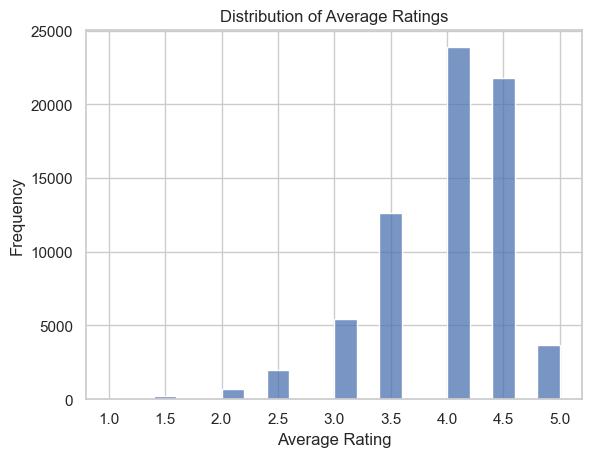

In [43]:
# Rating distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_final["avg_rating"], bins=20)
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

### Insight 1: Ratings are heavily concentrated

Online ratings compress quality differences, making it difficult to distinguish between average and truly outstanding restaurants. 

If almost all have a good score, then a 4.5 doesn't mean really good it might mean normal. Ratings are not telling the whole story

From a professional perspective, this is problematic:

In a real culinary evaluation, quality differences between restaurants can be significant, but such differences are not reflected in the rating distribuition
this is both frustrating for the professional and for the customer in the seek of a good place to eat.

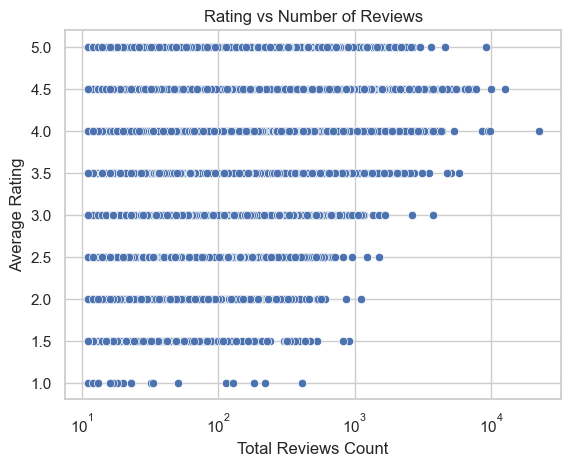

In [57]:
#Review vs rating
sns.scatterplot(x="total_reviews_count", y="avg_rating", data=df_final)
plt.xscale("log")
plt.title("Rating vs Number of Reviews")
plt.xlabel("Total Reviews Count")
plt.ylabel("Average Rating")
plt.show()

### Insight 2: Restaurants with few reviews show instable ratings as predicted

On the left (fewer reviews) we have restaurants with 1, 5 or any number of ratings (highly variable), in the right (more reviews) the ratings tend to concentrate from 3.5-4.5.

We can say that the rating tends to normalize, less extremes or "more reliable".

While that is actually true, and ratings based on a small number of reviews should be treated with caution, we still have the problem mentioned in the insight 1.

That would mean that restaurants with more visibility tend to look more "average" an INFLATED average

And the ones that don't have visibility are not really reliable. 

A complicated scene. 

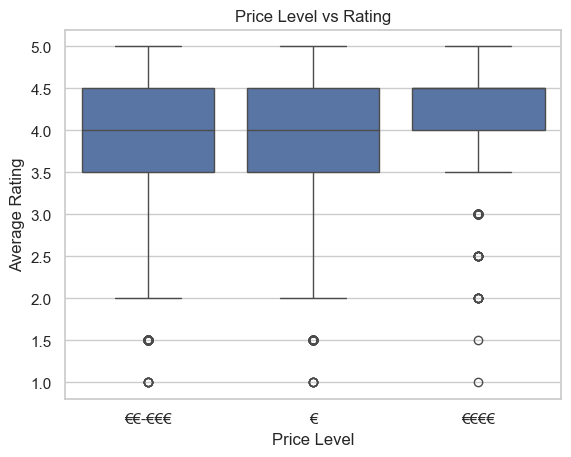

In [58]:
#Price level vs rating
sns.boxplot(x="price_level", y="avg_rating", data=df_final)
plt.title("Price Level vs Rating")
plt.xlabel("Price Level")
plt.ylabel("Average Rating")
plt.show()

### Insight 3: Paying more doesn't guarantee a better experience

The price doesn't change the average rating, although high-end restaurants show greater variability. That might be explained for the customer's expectations 

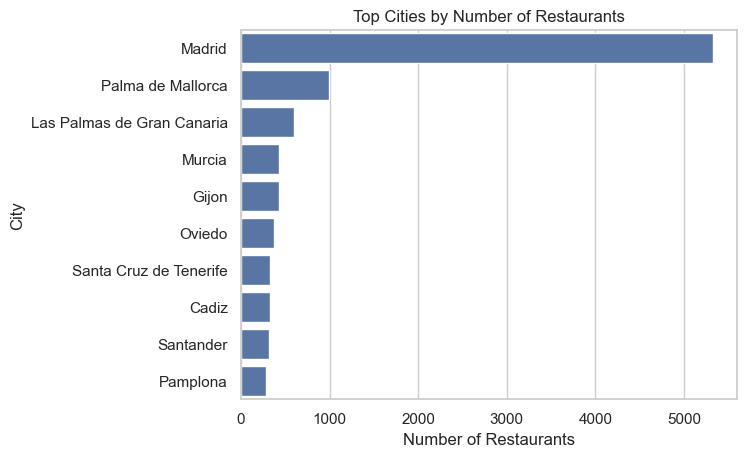

In [59]:
# Top 10 cities by number of restaurants
top_cities = df_final["city"].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

Madrid is by far the city with the most number of restaurants

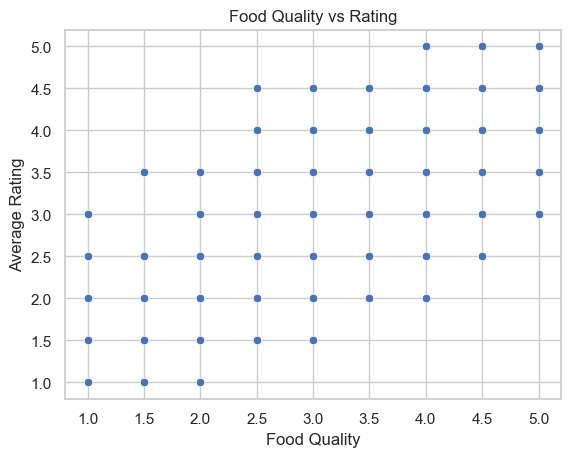

In [60]:
# Food vs rating
sns.scatterplot(x="food", y="avg_rating", data=df_final)
plt.title("Food Quality vs Rating")
plt.xlabel("Food Quality")
plt.ylabel("Average Rating")
plt.show()

### Insight 3: Food quality, the better the food is, the better the rating becomes

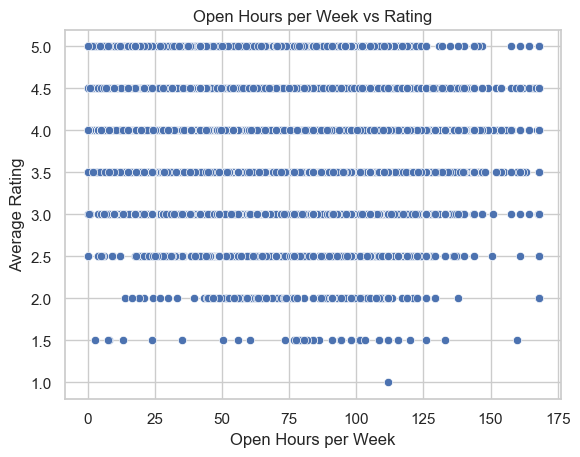

In [51]:
# Open hours per week vs rating # More hours = better rating? or creates burnout?
sns.scatterplot(x="open_hours_per_week", y="avg_rating", data=df_final)
plt.title("Open Hours per Week vs Rating")
plt.xlabel("Open Hours per Week")
plt.ylabel("Average Rating")
plt.show()

### Insight 4: Operational intensity (or open hours) doesn't necessarily improve ratings


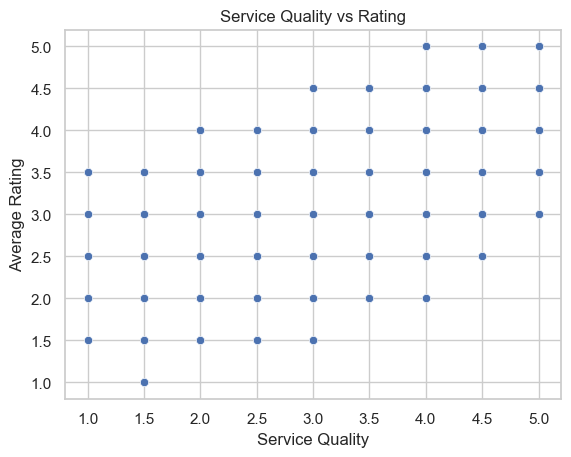

In [52]:
#Service vs rating
sns.scatterplot(x="service", y="avg_rating", data=df_final)
plt.title("Service Quality vs Rating")
plt.xlabel("Service Quality")
plt.ylabel("Average Rating")
plt.show()

<Axes: xlabel='value', ylabel='avg_rating'>

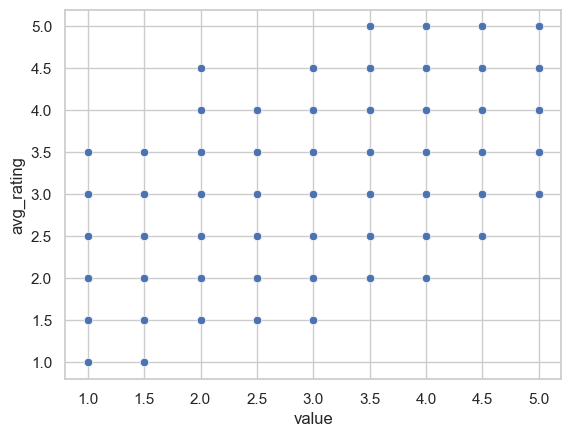

In [53]:
# Value 
sns.scatterplot(x="value", y="avg_rating", data=df_final)

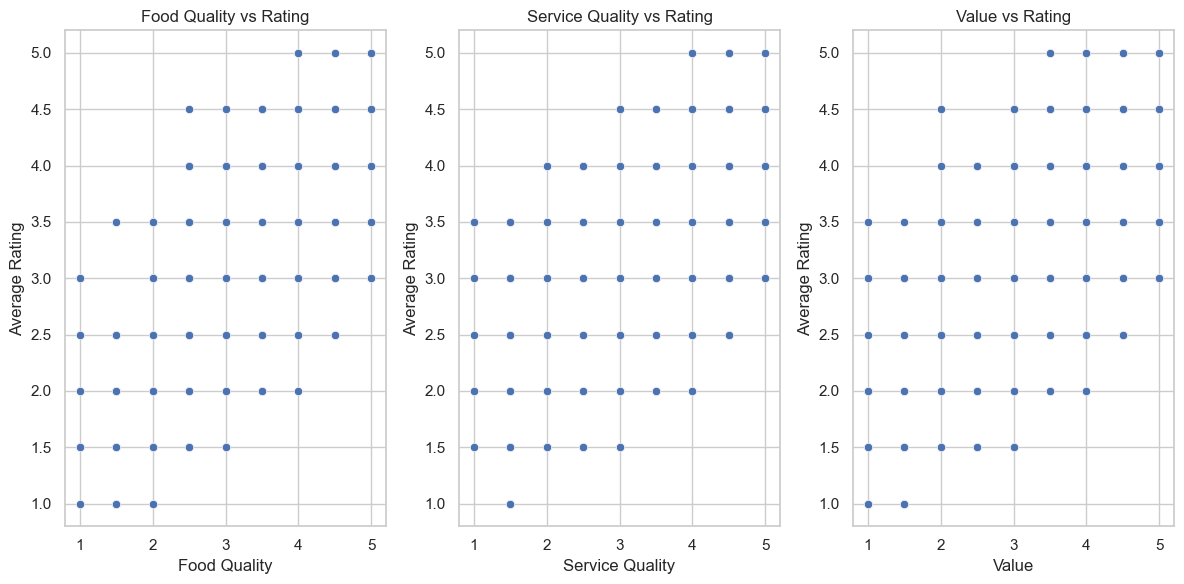

In [54]:
# let's put the food quality vs rating, food vs rating and service vs rating in the same plot to see if we can find some patterns
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.scatterplot(x="food", y="avg_rating", data=df_final)
plt.title("Food Quality vs Rating")
plt.xlabel("Food Quality")
plt.ylabel("Average Rating")

plt.subplot(1, 3, 2)
sns.scatterplot(x="service", y="avg_rating", data=df_final)
plt.title("Service Quality vs Rating")
plt.xlabel("Service Quality")
plt.ylabel("Average Rating")

plt.subplot(1, 3, 3)
sns.scatterplot(x="value", y="avg_rating", data=df_final)
plt.title("Value vs Rating")
plt.xlabel("Value")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [ ]:
# as we can see there is a positive correlation between all of them and the rating
# but we can see that the food quality has a stronger correlation with the rating than the service and value, which is something that we expected.  

In [55]:
# to see it more clearly we can calculate the correlation matrix of these three variables with the rating
correlation_matrix = df_final[["food", "service", "value", "avg_rating"]].corr()
print(correlation_matrix["avg_rating"].sort_values(ascending=False))


avg_rating    1.000000
food          0.813803
service       0.797632
value         0.754236
Name: avg_rating, dtype: float64
